In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [90]:
df =pd.read_csv("Offical Cash Rate (OCR) & 90 day bank bill rate.csv")
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    326 non-null    str    
 1   OCR     326 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.2 KB


,Date,OCR
0,30-04-2026,2.25
1,31-03-2026,2.25
2,28-02-2026,2.25
3,31-01-2026,2.25
4,31-12-2025,2.25
...,...,...
321,31-07-1999,4.50
322,30-06-1999,4.50
323,31-05-1999,4.50
324,30-04-1999,4.50


In [91]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")




/tmp/ipykernel_15604/3039054530.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


[*********************100%***********************]  1 of 1 completed

OCR    8.25
dtype: float64 OCR    0.25
dtype: float64


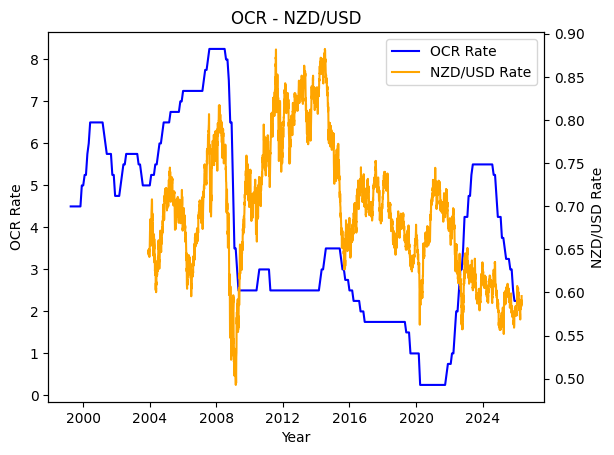

In [114]:
df_nzd = yf.download("NZDUSD=X", period="max")
df_sorted = df.sort_index()
max_ocr = df.max()
min_ocr = df.min()
print(max_ocr, min_ocr)

fig, ax = plt.subplots()
ax.plot(df_sorted.index, df_sorted, color="blue", label= "OCR Rate")
ax.set_title("OCR - NZD/USD")
ax.set_ylabel("OCR Rate")
ax2 = ax.twinx()
ax2.plot(df_nzd.index ,df_nzd["Close"], color= "orange", label= "NZD/USD Rate")
ax2.set_ylabel("NZD/USD Rate")
ax.set_xlabel("Year")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)

In [93]:
changes = df_sorted.diff()
grouped = changes[changes != 0].groupby(df_sorted.index.year).count()
grouped



,OCR
Date,
1999,1
2000,4
2001,5
2002,4
2003,3
2004,6
2005,3
2006,0
2007,4


In [94]:
max_change= df_sorted["OCR"].idxmax()
min_change= df_sorted["OCR"].idxmin()
print(max_change, min_change)

2007-07-31 00:00:00 2020-03-31 00:00:00


In [95]:
df_sorted["OCR"].idxmax()
df_sorted["OCR"].idxmin()

Timestamp('2020-03-31 00:00:00')